# Create Training Labels from the Critical Mineral Deposits Database

In [1]:

import geopandas as gpd

import sys
if sys.version_info < (3, 9):
    from importlib_resources import files
else:
    from importlib.resources import files

from beak.experimental.utilities.io import load_dataset
from beak.experimental.utilities.conversions import create_binary_raster

import numpy as np
import pandas as pd
from shapely.wkt import loads
import rasterio


# Definitions

In [2]:
# Set base paths and files
BASE_PATH = files("beak.data")

EPSG_CODE = 102008
RESOLUTION = 50
BASE_SPATIAL = str(EPSG_CODE) + "_" + str(RESOLUTION)
BASE_EXTENT = "mvt_southmid_cont"

BASE_RASTER = BASE_PATH / "BASE_RASTERS" / str("EPSG_" + str(EPSG_CODE) + "_RES_" + str(RESOLUTION) + "_" + BASE_EXTENT + ".tif")
base_raster = rasterio.open(BASE_RASTER)

# Points file and query to select relevant mineral occurences
PATH_LABELS = BASE_PATH / "RAW" / "mineral_deposits" / "Mississippi_Valley_Type" / "TA2_Pre_Hack_12M" / "set_20240609" / "zinc_mineral_site_data.csv"
PATH_LABELS_MC = BASE_PATH / "RAW" / "mineral_deposits" / "Mississippi_Valley_Type" / "TA2_McCafferty_CEUS_splits_from_hack_9m" / "train_test_valid.shp"
SQL_QUERY = "country == 'United States'"

# Set the output file
PATH_ROOT = BASE_PATH / "PROCESSED" / str("regional" + "_" + BASE_EXTENT + "_" + BASE_SPATIAL)
PATH_EXPORT = PATH_ROOT / "labels" / str("TA2_240609_HM9_MCCAFFERTY_TRAIN" + ".tif")
OUT_FILE = PATH_EXPORT

print(f"Output file: {OUT_FILE}")


Output file: S:\Projekte\20230082_DARPA_CriticalMAAS_TA3\Bearbeitung\GitHub\beak-ta3\src\beak\data\PROCESSED\regional_102008_50_mvt_southmid_cont\labels\EPSG_102008_RES_50_mvt_southmid_cont_TA2_240609_HM9_MCCAFFERTY_TRAIN.tif


# **Helper**

In [3]:
import matplotlib.pyplot as plt
def plot_histogram(df, column, num_bins=100):
    df['top1_deposit_classification_confidence'].hist(bins=num_bins)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f"Histogram of {column}")
    plt.show()

In [4]:
def count_values(df, column):    
    values = df[column].unique()
    values_df = pd.DataFrame(values, columns=[column])
    counts = df[column].value_counts()
    values_with_counts = counts.reset_index()
    values_with_counts.columns = [column, 'count']
    
    return values_with_counts


# **Load and initially clean data**

In [5]:
mineral_sites = gpd.read_file(PATH_LABELS)

mineral_sites = load_dataset(PATH_LABELS).query(SQL_QUERY)
mineral_sites = mineral_sites.dropna(subset=["loc_wkt"])
mineral_sites["geometry"] = mineral_sites["loc_wkt"].apply(loads)
mineral_sites = gpd.GeoDataFrame(mineral_sites, geometry="geometry")
mineral_sites = mineral_sites.explode(ignore_index=True)
mineral_sites = mineral_sites.drop_duplicates(subset=["geometry"])
mineral_sites = mineral_sites.set_crs("EPSG:4326")

mineral_sites

,group_id,ms,ms_name,ms_type,ms_rank,country,state_or_province,loc_crs,loc_wkt,top1_deposit_type,top1_deposit_group,top1_deposit_environment,top1_deposit_classification_confidence,top1_deposit_classification_source,geometry
0,65,['https://minmod.isi.edu/resource/site__api-cd...,['NI 43-101 Technical Report for the Red Dog P...,NaN,NaN,United States,Alaska,EPSG:4326,GEOMETRYCOLLECTION (MULTIPOINT (-162.824999999...,Irish-type sediment- hosted zinc- lead,Sediment-hosted,Basin hydrothermal,1.00000,report,"MULTIPOINT ((-162.82500 -68.07083), (-162.8297..."
1,65,['https://minmod.isi.edu/resource/site__api-cd...,['NI 43-101 Technical Report for the Red Dog P...,NaN,NaN,United States,Alaska,EPSG:4326,GEOMETRYCOLLECTION (MULTIPOINT (-162.824999999...,Irish-type sediment- hosted zinc- lead,Sediment-hosted,Basin hydrothermal,1.00000,report,MULTIPOINT ((-163.03450 68.06910))
2,101,https://minmod.isi.edu/resource/site__api-cdr-...,NI 43-101 Technical Report for the Back Forty ...,NaN,NaN,United States,Michigan,EPSG:4326,POINT(-87.6189 45.4133),MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.08481,"algorithm predictions, SRI deposit type classi...",POINT (-87.61890 45.41330)
3,128,['https://minmod.isi.edu/resource/site__w3id-o...,['NI 43-101 Technical Report (OM) for the Gree...,NaN,NaN,United States,Alaska,EPSG:4326,GEOMETRYCOLLECTION (MULTIPOINT (-134.370560000...,Bimodal felsic VMS,Volcanogenic massive sulfide (VMS),Volcanic basin hydrothermal,1.00000,report,MULTIPOINT ((-134.37056 57.84615))
4,128,['https://minmod.isi.edu/resource/site__w3id-o...,['NI 43-101 Technical Report (OM) for the Gree...,NaN,NaN,United States,Alaska,EPSG:4326,GEOMETRYCOLLECTION (MULTIPOINT (-134.370560000...,Bimodal felsic VMS,Volcanogenic massive sulfide (VMS),Volcanic basin hydrothermal,1.00000,report,POINT (-134.39530 57.84610)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19048,43749,https://minmod.isi.edu/resource/site__mrdata-u...,Jackson Mine,Prospect,D,United States,Nevada,EPSG:4326,POINT (-115.73277 37.53886),Supergene lead,Supergene,Supergene,0.12614,"algorithm predictions, SRI deposit type classi...",POINT (-115.73277 37.53886)
19049,50162,https://minmod.isi.edu/resource/site__mrdata-u...,Lakeview Lead Silver,Unknown,D,United States,Nevada,EPSG:4326,POINT (-118.60906 38.70772),Supergene silver,Supergene,Supergene,0.14231,"algorithm predictions, SRI deposit type classi...",POINT (-118.60906 38.70772)
19050,50163,https://minmod.isi.edu/resource/site__mrdata-u...,Apex-Fawn,Prospect,E,United States,Nevada,EPSG:4326,POINT (-118.35924 37.90273),Black shale gold,Black shale,Basin chemical,0.15869,"algorithm predictions, SRI deposit type classi...",POINT (-118.35924 37.90273)
19051,50168,https://minmod.isi.edu/resource/site__mrdata-u...,Unnamed Prospect,Prospect,D,United States,Nevada,EPSG:4326,POINT (-114.24771 36.35309),Replacement polymetallic,Replacement,Magmatic hydrothermal,0.18359,"algorithm predictions, SRI deposit type classi...",POINT (-114.24771 36.35309)


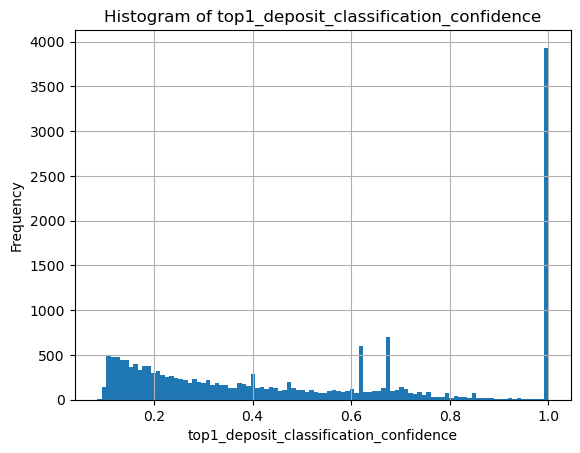

In [6]:
plot_histogram(mineral_sites, "top1_deposit_classification_confidence")

## Check data and filtering

In [7]:
count_values(mineral_sites[mineral_sites["top1_deposit_group"] == "Mississippi Valley- type (MVT)"], 'top1_deposit_type')


,top1_deposit_type,count
0,MVT zinc-lead,5471
1,Sandstone-hosted zinc-lead,248
2,MVT fluorspar,74
3,MVT barite,17


In [8]:
count_values(mineral_sites, 'top1_deposit_group')


,top1_deposit_group,count
0,Mississippi Valley- type (MVT),5810
1,Replacement,2428
2,Vein,2367
3,Skarn,1567
4,Supergene,1145
5,Epithermal,1135
6,Orogenic,914
7,Placer,617
8,Volcanogenic massive sulfide (VMS),453
9,Intrusion-related,325


In [9]:
count_values(mineral_sites, 'top1_deposit_environment')

,top1_deposit_environment,count
0,Magmatic hydrothermal,8558
1,Basin hydrothermal,6286
2,Supergene,1249
3,Metamorphic hy- drothermal,655
4,Erosional,617
5,Volcanic basin hydrothermal,477
6,Metamorphic hydrothermal,259
7,Basin chemical,243
8,Basin evaporative,197
9,Infiltrational,82


# Export to GeoPackages
## All Points

In [10]:
out_file = str(PATH_LABELS.parent / str(PATH_LABELS.stem)) + ".gpkg"


In [11]:
mineral_sites.to_file(out_file, layer="mineral_sites", driver="GPKG")


## Filtered Points

In [12]:
query = "top1_deposit_type == 'MVT zinc-lead' and top1_deposit_classification_confidence >= 0.5 and ms_type in ('Past Producer', 'Prospect', 'Producer') and ms_rank in ('A', 'B', 'C')"
mineral_sites_filtered = mineral_sites.query(query)
mineral_sites_filtered

,group_id,ms,ms_name,ms_type,ms_rank,country,state_or_province,loc_crs,loc_wkt,top1_deposit_type,top1_deposit_group,top1_deposit_environment,top1_deposit_classification_confidence,top1_deposit_classification_source,geometry
178,1206,https://minmod.isi.edu/resource/site__mrdata-u...,Blue Bonnett Mine,Past Producer,B,United States,Oklahoma,EPSG:4326,POINT (-94.77884 36.98617),MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.50751,"algorithm predictions, SRI deposit type classi...",POINT (-94.77884 36.98617)
182,1212,https://minmod.isi.edu/resource/site__mrdata-u...,Mission Mine,Past Producer,B,United States,Oklahoma,EPSG:4326,POINT (-94.78444 36.97837),MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.68926,"algorithm predictions, SRI deposit type classi...",POINT (-94.78444 36.97837)
395,1467,['https://minmod.isi.edu/resource/site__mrdata...,Osborn Mine,Past Producer,B,United States,Virginia,EPSG:4326,GEOMETRYCOLLECTION (POINT (-82.239850000000004...,MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.63073,"algorithm predictions, SRI deposit type classi...",POINT (-82.23985 36.80758)
396,1467,['https://minmod.isi.edu/resource/site__mrdata...,Osborn Mine,Past Producer,B,United States,Virginia,EPSG:4326,GEOMETRYCOLLECTION (POINT (-82.239850000000004...,MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.63073,"algorithm predictions, SRI deposit type classi...",POINT (-82.26402 36.79925)
553,1646,https://minmod.isi.edu/resource/site__mrdata-u...,Pend Oreille Mine,Producer,B,United States,Washington,EPSG:4326,POINT (-117.35645 48.88333),MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.57601,"algorithm predictions, SRI deposit type classi...",POINT (-117.35645 48.88333)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18061,42461,https://minmod.isi.edu/resource/site__mrdata-u...,Ivanhoe Lead Zinc Mine,Past Producer,A,United States,Virginia,EPSG:4326,POINT (-80.96203 36.83424),MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.87489,"algorithm predictions, SRI deposit type classi...",POINT (-80.96203 36.83424)
18065,42469,https://minmod.isi.edu/resource/site__mrdata-u...,Friedensville Mine,Past Producer,A,United States,Pennsylvania,EPSG:4326,POINT (-75.40462 40.55445),MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.84264,"algorithm predictions, SRI deposit type classi...",POINT (-75.40462 40.55445)
18598,49087,https://minmod.isi.edu/resource/site__mrdata-u...,Harris Mine,Past Producer,B,United States,Kansas,EPSG:4326,POINT (-94.81664 37.06257),MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.71329,"algorithm predictions, SRI deposit type classi...",POINT (-94.81664 37.06257)
18812,49857,https://minmod.isi.edu/resource/site__mrdata-u...,Brugger Tract,Past Producer,B,United States,Kansas,EPSG:4326,POINT (-94.75914 37.03397),MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.53043,"algorithm predictions, SRI deposit type classi...",POINT (-94.75914 37.03397)


## Add McCafferty Data

In [13]:
# Labels MC
labels_mc = gpd.read_file(PATH_LABELS_MC)
labels_mc



,label,lon,lat,source,geometry
0,1.0,100750.0,-355750.0,train,POINT (100750.000 -355750.000)
1,1.0,98250.0,-355750.0,train,POINT (98250.000 -355750.000)
2,1.0,103250.0,-352250.0,train,POINT (103250.000 -352250.000)
3,1.0,105250.0,-350250.0,train,POINT (105250.000 -350250.000)
4,1.0,101750.0,-356750.0,train,POINT (101750.000 -356750.000)
...,...,...,...,...,...
3802,1.0,421250.0,-219250.0,valid,POINT (421250.000 -219250.000)
3803,1.0,96250.0,-357250.0,valid,POINT (96250.000 -357250.000)
3804,1.0,100750.0,-356750.0,valid,POINT (100750.000 -356750.000)
3805,1.0,431250.0,299750.0,valid,POINT (431250.000 299750.000)


In [14]:
labels_mc = labels_mc[labels_mc["source"] == "train"]

In [28]:
# Merge
mineral_sites_filtered["source"] = "mineral_sites"
labels = pd.concat([mineral_sites_filtered[["source", "geometry"]].to_crs(base_raster.crs), 
                    labels_mc[["source", "geometry"]].to_crs(base_raster.crs)], ignore_index=True)


C:\Users\steffen\.conda\envs\beak-ta3\lib\site-packages\geopandas\geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


# Create Labels

In [29]:
data = labels.copy()
data = data.explode(ignore_index=True)
data = data[~data.is_empty]
data = data.reset_index(drop=True)
data = data.to_crs(base_raster.crs)


In [30]:
labels_array = create_binary_raster(data, base_raster, all_touched=False, same_shape=True, fill_negatives=True, out_file=PATH_EXPORT)
print(f"Number of positive training labels: {np.sum(labels_array==1)}")

File already exists: EPSG_102008_RES_50_mvt_southmid_cont_TA2_240609_HM9_MCCAFFERTY_TRAIN.tif.
Number of positive training labels: 33
